In [1]:
import mne
mne.set_log_level('error')

import numpy as np
import matplotlib.pyplot as plt
import glob

In [2]:
# Import raw data
glob.glob('Raw/Sub_1/Subject 1*')

['Raw/Sub_1\\Subject 1, Session 1, Block 1 Recording_FLEX2_213075_2025.01.25T15.18.28.08.00.json',
 'Raw/Sub_1\\Subject 1, Session 1, Block 1 Recording_FLEX2_213075_2025.01.25T15.18.28.08.00.md.edf',
 'Raw/Sub_1\\Subject 1-ica.fif',
 'Raw/Sub_1\\Subject 1-raw.fif',
 'Raw/Sub_1\\Subject 1-raw_filt.fif',
 'Raw/Sub_1\\Subject 1-raw_ica.fif']

In [3]:
raw = mne.io.read_raw_edf('Raw/Sub_1/Subject 1, Session 1, Block 1 Recording_FLEX2_213075_2025.01.25T15.18.28.08.00.md.edf',preload=True)

In [4]:
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: TimestampS, TimestampMs, OrTimestampS, OrTimestampMs, Counter, ...
 chs: 127 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2025-01-25 15:18:28 UTC
 nchan: 127
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

In [5]:
raw.info['ch_names']

['TimestampS',
 'TimestampMs',
 'OrTimestampS',
 'OrTimestampMs',
 'Counter',
 'Interpolated',
 'Cz',
 'FCz',
 'Afz',
 'Fp1',
 'F5',
 'F1',
 'CP5',
 'CP3',
 'CP1',
 'P1',
 'P3',
 'P5',
 'P7',
 'PO7',
 'PO3',
 'O1',
 'Pz',
 'POz',
 'Oz',
 'O2',
 'PO4',
 'PO8',
 'P8',
 'P6',
 'P4',
 'P2',
 'CP2',
 'CP4',
 'CP6',
 'F2',
 'F6',
 'Fp2',
 'RawCq',
 'Battery',
 'BatteryPercent',
 'FwBufferSize',
 'FwClockTime',
 'MarkerHardware',
 'CQ.Cz',
 'CQ.FCz',
 'CQ.Afz',
 'CQ.Fp1',
 'CQ.F5',
 'CQ.F1',
 'CQ.CP5',
 'CQ.CP3',
 'CQ.CP1',
 'CQ.P1',
 'CQ.P3',
 'CQ.P5',
 'CQ.P7',
 'CQ.PO7',
 'CQ.PO3',
 'CQ.O1',
 'CQ.Pz',
 'CQ.POz',
 'CQ.Oz',
 'CQ.O2',
 'CQ.PO4',
 'CQ.PO8',
 'CQ.P8',
 'CQ.P6',
 'CQ.P4',
 'CQ.P2',
 'CQ.CP2',
 'CQ.CP4',
 'CQ.CP6',
 'CQ.F2',
 'CQ.F6',
 'CQ.Fp2',
 'CQ.Overall',
 'EQ.SampleRateQua',
 'EQ.OVERALL',
 'EQ.Cz',
 'EQ.FCz',
 'EQ.Afz',
 'EQ.Fp1',
 'EQ.F5',
 'EQ.F1',
 'EQ.CP5',
 'EQ.CP3',
 'EQ.CP1',
 'EQ.P1',
 'EQ.P3',
 'EQ.P5',
 'EQ.P7',
 'EQ.PO7',
 'EQ.PO3',
 'EQ.O1',
 'EQ.Pz',
 'EQ.POz'

In [6]:
raw.__dict__

{'_last_samps': array([76031]),
 '_first_samps': array([0]),
 'info': <Info | 8 non-empty values
  bads: []
  ch_names: TimestampS, TimestampMs, OrTimestampS, OrTimestampMs, Counter, ...
  chs: 127 EEG
  custom_ref_applied: False
  highpass: 0.0 Hz
  lowpass: 128.0 Hz
  meas_date: 2025-01-25 15:18:28 UTC
  nchan: 127
  projs: []
  sfreq: 256.0 Hz
  subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
 >,
 'buffer_size_sec': 1.0,
 '_cals': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 

In [7]:
# To set target channels
target_channels = [
    'Cz', 'FCz', 'Afz', 'Fp1', 'F5', 'F1', 'CP5', 'CP3', 'CP1', 'P1', 
    'P3', 'P5', 'P7', 'PO7', 'PO3', 'O1', 'Pz', 'POz', 'Oz', 'O2', 
    'PO4', 'PO8', 'P8', 'P6', 'P4', 'P2', 'CP2', 'CP4', 'CP6', 'F2', 
    'F6', 'Fp2'
]

raw.pick_channels(target_channels)

<RawEDF | Subject 1, Session 1, Block 1 Recording_FLEX2_213075_2025.01.25T15.18.28.08.00.md.edf, 32 x 76032 (297.0 s), ~18.6 MiB, data loaded>

In [8]:
raw.plot(duration = 1);
plt.show()

In [9]:
# Rename channel to standard
raw.rename_channels({'Afz': 'AFz'})

<RawEDF | Subject 1, Session 1, Block 1 Recording_FLEX2_213075_2025.01.25T15.18.28.08.00.md.edf, 32 x 76032 (297.0 s), ~18.6 MiB, data loaded>

In [10]:
raw.set_montage('standard_1020')

<RawEDF | Subject 1, Session 1, Block 1 Recording_FLEX2_213075_2025.01.25T15.18.28.08.00.md.edf, 32 x 76032 (297.0 s), ~18.6 MiB, data loaded>

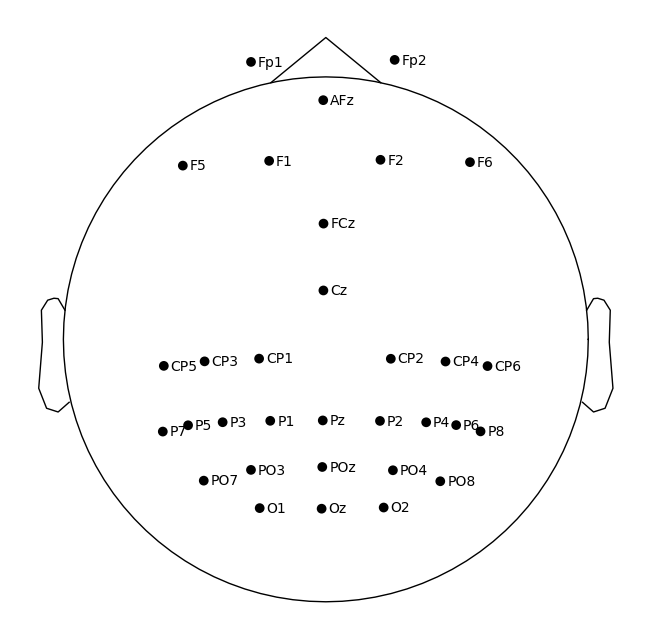

In [11]:
raw.plot_sensors(show_names=True);

In [12]:
mne.events_from_annotations(raw)

(array([[  116,     0,   569],
        [  172,     0,  1037],
        [  223,     0,   550],
        ...,
        [75592,     0,   784],
        [75644,     0,   662],
        [75991,     0,    18]], shape=(1071, 3)),
 {np.str_('behav,2,-1,103'): 1,
  np.str_('behav,2,-1,465'): 2,
  np.str_('behav,2,-1,801'): 3,
  np.str_('behav,2,-1,822'): 4,
  np.str_('behav,2,-1,885'): 5,
  np.str_('behav,2,-1,906'): 6,
  np.str_('behav,3,-1,1011'): 7,
  np.str_('behav,3,-1,1032'): 8,
  np.str_('behav,3,-1,1053'): 9,
  np.str_('behav,3,-1,124'): 10,
  np.str_('behav,3,-1,145'): 11,
  np.str_('behav,3,-1,166'): 12,
  np.str_('behav,3,-1,187'): 13,
  np.str_('behav,3,-1,208'): 14,
  np.str_('behav,3,-1,21'): 15,
  np.str_('behav,3,-1,229'): 16,
  np.str_('behav,3,-1,250'): 17,
  np.str_('behav,3,-1,271'): 18,
  np.str_('behav,3,-1,276'): 19,
  np.str_('behav,3,-1,297'): 20,
  np.str_('behav,3,-1,318'): 21,
  np.str_('behav,3,-1,339'): 22,
  np.str_('behav,3,-1,360'): 23,
  np.str_('behav,3,-1,381'): 2

c:\Users\Sam\anaconda3\envs\neural_data_science\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


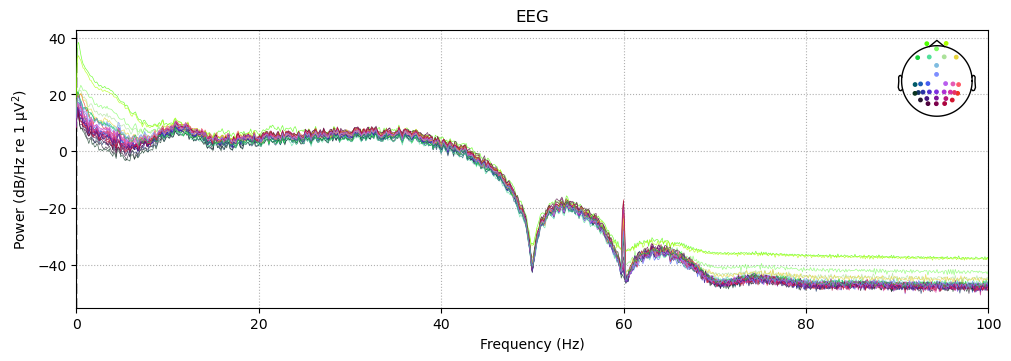

In [13]:
raw.plot_psd(fmax=100);

In [14]:
# set filter parameters
low_cut = 0.1
hi_cut = 40

raw_filt = raw.copy().filter(low_cut, hi_cut)

c:\Users\Sam\anaconda3\envs\neural_data_science\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


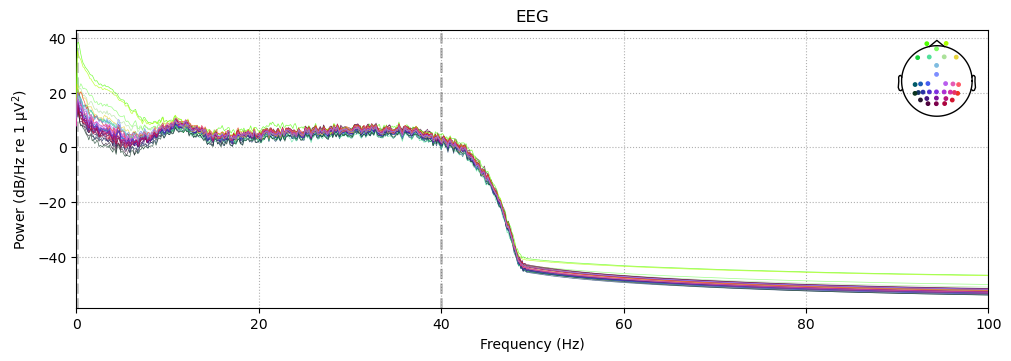

In [15]:
raw_filt.plot_psd(fmax=100);

In [16]:
raw_filt.plot(start=15, duration=5)

In [17]:
# save raw data
raw.save('Raw/Sub_1/Subject 1' + '-raw.fif',
            overwrite=True)

[WindowsPath('c:/Users/Sam/Documents/GitHub/Alljoined_prepro/Raw/Sub_1/Subject 1-raw.fif')]

In [18]:
# save filtered data
raw_filt.save('Raw/Sub_1/Subject 1' + '-raw_filt.fif',
            overwrite=True)

[WindowsPath('c:/Users/Sam/Documents/GitHub/Alljoined_prepro/Raw/Sub_1/Subject 1-raw_filt.fif')]

In [19]:
# begin Independent Component Analysis, 
# filter for ICA

ica_low_cut = 1.0
hi_cut = 30

raw_ica = raw.copy().filter(ica_low_cut, hi_cut)

In [20]:
# save ICA data
raw_ica.save('Raw/Sub_1/Subject 1' + '-raw_ica.fif',
            overwrite=True)

[WindowsPath('c:/Users/Sam/Documents/GitHub/Alljoined_prepro/Raw/Sub_1/Subject 1-raw_ica.fif')]

In [21]:
# Epoching for ICA
tstep = 1.0
events_ica = mne.make_fixed_length_events(raw_ica, duration=tstep)
epochs_ica = mne.Epochs(raw_ica, events_ica,
                        tmin=0.0, tmax=tstep,
                        baseline=None, preload=True)

In [22]:
# Set autoreject threshold

from autoreject import get_rejection_threshold

reject = get_rejection_threshold(epochs_ica);
print(reject)

Estimating rejection dictionary for eeg
{'eeg': np.float64(0.0002739529250544432)}


In [23]:
# Run ICA

random_state = 42
ica_n_components = .99

ica = mne.preprocessing.ICA(n_components=ica_n_components,
                            random_state=random_state,
                            )

ica.fit(epochs_ica,
        reject=reject,
        tstep=tstep)

Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,35 iterations on epochs (76072 samples)
ICA components,19
Available PCA components,32
Channel types,eeg
ICA components marked for exclusion,—


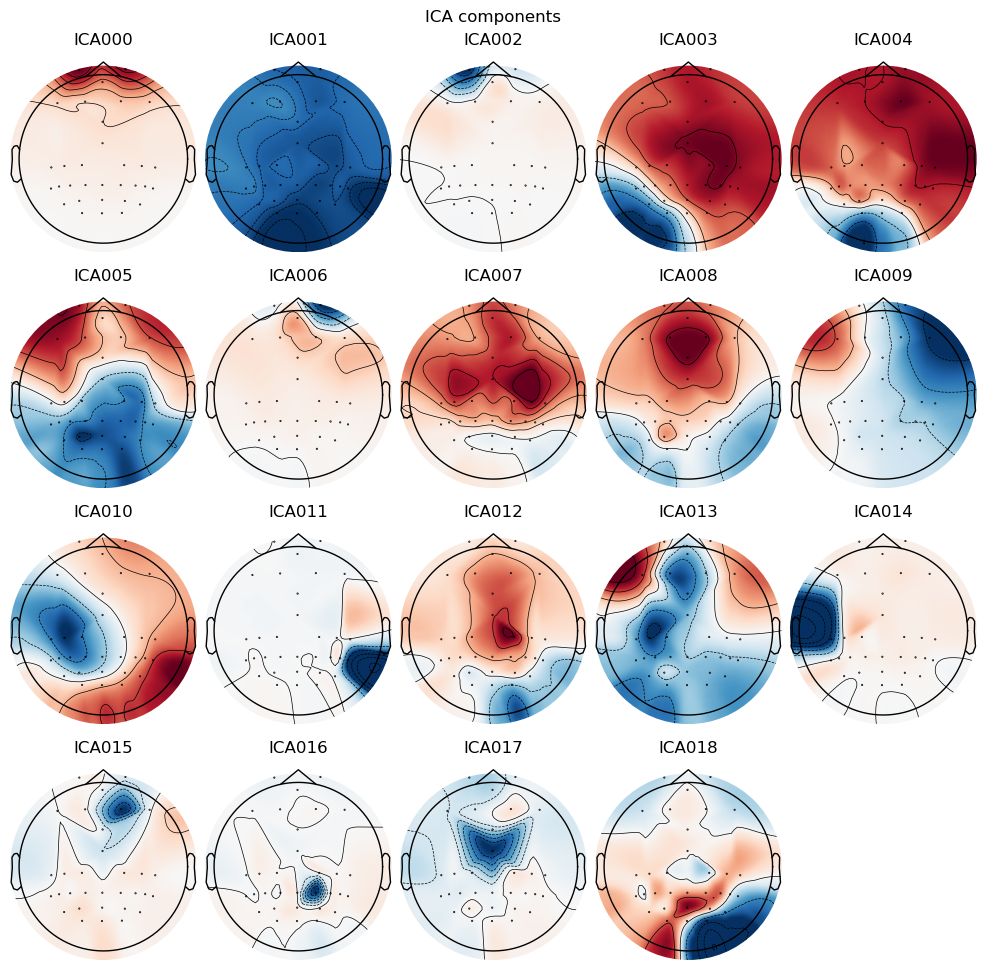

In [24]:
ica.plot_components();

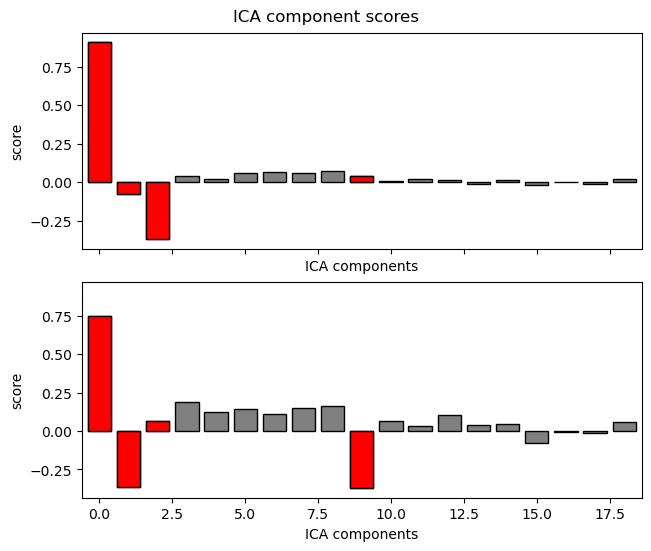

In [25]:
ica_z_thresh = 1.96
eog_indices, eog_scores = ica.find_bads_eog(raw_ica,
                                            ch_name=['Fp1', 'F6'],
                                            threshold=ica_z_thresh
                                            )

ica.exclude = eog_indices

ica.plot_scores(eog_scores);

In [26]:
# Save final ICA output
ica.save('Raw/Sub_1/Subject 1' + '-ica.fif',
            overwrite=True)

Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,35 iterations on epochs (76072 samples)
ICA components,19
Available PCA components,32
Channel types,eeg
ICA components marked for exclusion,ICA000ICA009ICA002ICA001


In [27]:
# Pull event references for main Epoching

events, event_dict = mne.events_from_annotations(raw)

In [28]:
event_dict

{np.str_('behav,2,-1,103'): 1,
 np.str_('behav,2,-1,465'): 2,
 np.str_('behav,2,-1,801'): 3,
 np.str_('behav,2,-1,822'): 4,
 np.str_('behav,2,-1,885'): 5,
 np.str_('behav,2,-1,906'): 6,
 np.str_('behav,3,-1,1011'): 7,
 np.str_('behav,3,-1,1032'): 8,
 np.str_('behav,3,-1,1053'): 9,
 np.str_('behav,3,-1,124'): 10,
 np.str_('behav,3,-1,145'): 11,
 np.str_('behav,3,-1,166'): 12,
 np.str_('behav,3,-1,187'): 13,
 np.str_('behav,3,-1,208'): 14,
 np.str_('behav,3,-1,21'): 15,
 np.str_('behav,3,-1,229'): 16,
 np.str_('behav,3,-1,250'): 17,
 np.str_('behav,3,-1,271'): 18,
 np.str_('behav,3,-1,276'): 19,
 np.str_('behav,3,-1,297'): 20,
 np.str_('behav,3,-1,318'): 21,
 np.str_('behav,3,-1,339'): 22,
 np.str_('behav,3,-1,360'): 23,
 np.str_('behav,3,-1,381'): 24,
 np.str_('behav,3,-1,402'): 25,
 np.str_('behav,3,-1,42'): 26,
 np.str_('behav,3,-1,423'): 27,
 np.str_('behav,3,-1,444'): 28,
 np.str_('behav,3,-1,486'): 29,
 np.str_('behav,3,-1,507'): 30,
 np.str_('behav,3,-1,528'): 31,
 np.str_('behav,

In [42]:
import json

# Replace with the exact name of your downloaded JSON file
json_file_path = "Raw/Sub_1/Subject 1, Session 1, Block 1 Recording_FLEX2_213075_2025.01.25T15.18.28.08.00.json"

# Open and load the dictionary
with open(json_file_path, 'r') as file:
    events_data = json.load(file)

# Let's peek at the first few entries to understand their structure
# (We use list slicing if it's a list, or just print the keys if it's a dict)
if isinstance(events_data, list):
    print("First 3 events:", events_data[:3])
elif isinstance(events_data, dict):
    # Print the top-level categories to see where the markers are hidden
    print("JSON Keys:", events_data.keys())

JSON Keys: dict_keys(['Markers', 'connectionType', 'exportApp', 'exportTime', 'headsetType', 'mappings', 'montageType', 'recordId', 'user'])


In [43]:
# 1. Look at the dictionary translating codes to names
print("Mappings:", events_data['mappings'])

# 2. Look at the first 3 events in the timeline
print("\nFirst 3 Markers:", events_data['Markers'][:3])

Mappings: {'CMS': 'TP9', 'DRL': 'TP10', 'LA': 'P3', 'LB': 'P7', 'LC': 'P1', 'LD': 'CP1', 'LE': 'CP5', 'LF': 'F1', 'LG': 'F5', 'LH': 'Fp1', 'LJ': 'POz', 'LK': 'Pz', 'LL': 'Afz', 'LM': 'CP3', 'LN': 'O1', 'LO': 'PO7', 'LP': 'PO3', 'LQ': 'P5', 'RA': 'P4', 'RB': 'P8', 'RC': 'P2', 'RD': 'CP2', 'RE': 'CP6', 'RF': 'F2', 'RG': 'F6', 'RH': 'Fp2', 'RJ': 'Oz', 'RK': 'Cz', 'RL': 'O2', 'RM': 'CP4', 'RN': 'FCz', 'RO': 'PO8', 'RP': 'PO4', 'RQ': 'P6'}

First 3 Markers: [{'deleted': False, 'endDatetime': '2025-01-25T15:18:28.641652-08:00', 'extras': {}, 'index': 1, 'label': 'stim_test', 'originalEndDatetime': '2025-01-25T15:18:28.642285-08:00', 'originalStartDatetime': '2025-01-25T15:18:28.642285-08:00', 'port': 'Software', 'startDatetime': '2025-01-25T15:18:28.641652-08:00', 'type': 'instance', 'uuid': 'b85fa835-9fe5-4b07-8139-f92e36108c86', 'value': 16641}, {'deleted': False, 'endDatetime': '2025-01-25T15:18:28.860378-08:00', 'extras': {}, 'index': 2, 'label': 'stim_test', 'originalEndDatetime': '2025